# Telco Customer Churn — Predictive Retention Analysis
## Notebook 02 · Clean & Transform

| | |
|---|---|
| **Author** | Natalia Stekolnikova |
| **Course** | IFCT153PO — Big Data & Business Intelligence |
| **Input** | `data/WA_Fn-UseC_-Telco-Customer-Churn.csv` |
| **Output** | `outputs/telco_clean.csv` · `outputs/telco_model_ready.csv` |

---

### Purpose of this notebook

Notebook 01 **detected** data quality issues. This notebook **fixes** them
in a deliberate, documented order — then engineers one new feature
and produces two output files with different purposes.

### Two output files — why different?

| File | Purpose | Contains |
|---|---|---|
| `telco_clean.csv` | SQL  | Human-readable strings + business features |
| `telco_model_ready.csv` | ML training only | All-numeric, no redundant features |

### Transformation pipeline

```
RAW DATA (7,043 rows · 21 cols)
    │
    ├── 1. FIX    TotalCharges  object → float64  + impute 11 blanks
    ├── 2. FIX    SeniorCitizen 0/1   → Yes/No    (consistency)
    ├── 3. CLEAN  7 service columns   → collapse redundant labels
    ├── 4. CAST   16 string columns   → category  (memory optimisation)
    ├── 5. ENCODE Churn               → int64 (1=Yes, 0=No)
    ├── 6. ENGINEER NumServices       → only valid engineered feature
    ├── 7. SAVE   telco_clean.csv     → + TenureGroup, IsAutoPayment for reporting
    └── 8. ENCODE for ML             → Label + One-Hot → telco_model_ready.csv
```

### Feature engineering decision log

Four engineered features were evaluated. Three rejected for multicollinearity:

| Feature | Decision | Mathematical reason |
|---|---|---|
| `TenureGroup` | **REJECTED from ML** | r=0.961 with tenure, discretisation loses info |
| `IsAutoPayment` | **REJECTED from ML** | 100% reconstructable from PM_Electronic + PM_Mailed |
| `NumServices` | **ACCEPTED** | Non-linear churn signal (peak at NS=3: 44.9%) not captured by MonthlyCharges |

`TenureGroup` and `IsAutoPayment` are kept in `telco_clean.csv` for SQL queries
and Power BI dashboards where they have real business value.

---
## 0 · Environment

In [3]:
import warnings
import pandas as pd
import numpy as np
from pathlib import Path
from pandas.api.types import CategoricalDtype
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.figsize'   : (12, 4),
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 12,
    'axes.titleweight' : 'bold',
    'font.size'        : 10,
})
C_CHURN = '#e74c3c'
C_STAY  = '#2ecc71'
C_BLUE  = '#3498db'

# Portable paths
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / 'data').exists() \
               else NOTEBOOK_DIR
DATA_DIR   = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILE = DATA_DIR / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
assert DATA_FILE.exists(), f'Dataset not found: {DATA_FILE}'

# Load
df_raw = pd.read_csv(DATA_FILE)
df     = df_raw.copy()

print(f'Loaded  : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Outputs : {OUTPUT_DIR}')

Loaded  : 7,043 rows × 21 columns
Outputs : C:\Users\natal\Documents\churn_project\outputs


---
## 1 · Fix: TotalCharges — object → float64

### Problem
11 cells contain a blank string `' '` instead of a number.
pandas stored the entire column as `object` — unusable for arithmetic or ML.

### Why these 11 rows have blanks
All 11 have `tenure = 0` — new customers whose first invoice has not yet been posted.
Their `TotalCharges` is not truly missing — it equals `MonthlyCharges` (first month billing).

### Imputation strategy: domain-driven
We impute `TotalCharges ← MonthlyCharges` — a business rule, not a statistical estimate.
This is more accurate than mean/median imputation because it reflects reality.

In [5]:
# Step 1a: coerce blanks to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_nan = df['TotalCharges'].isna().sum()
print(f'NaN after coerce: {n_nan}  (these are the 11 blank strings)')

# Step 1b: domain-driven imputation
mask_nan = df['TotalCharges'].isna()
df.loc[mask_nan, 'TotalCharges'] = df.loc[mask_nan, 'MonthlyCharges']

# Verify
print(f'NaN after imputation: {df["TotalCharges"].isna().sum()}  ← must be 0')
print(f'dtype after fix     : {df["TotalCharges"].dtype}  ← must be float64')
print()
print('Imputed rows (TotalCharges = MonthlyCharges = first month billing):')
display(
    df.loc[mask_nan,
           ['customerID','tenure','MonthlyCharges','TotalCharges','Contract']]
)
print()
print('Note: all 10 Two-year + 1 One-year contracts — committed customers.')
print('None of them churned. Domain imputation is more accurate than mean/median.')

NaN after coerce: 11  (these are the 11 blank strings)
NaN after imputation: 0  ← must be 0
dtype after fix     : float64  ← must be float64

Imputed rows (TotalCharges = MonthlyCharges = first month billing):


,customerID,tenure,MonthlyCharges,TotalCharges,Contract
488,4472-LVYGI,0,52.5500,52.5500,Two year
753,3115-CZMZD,0,20.2500,20.2500,Two year
936,5709-LVOEQ,0,80.8500,80.8500,Two year
1082,4367-NUYAO,0,25.7500,25.7500,Two year
1340,1371-DWPAZ,0,56.0500,56.0500,Two year
3331,7644-OMVMY,0,19.8500,19.8500,Two year
3826,3213-VVOLG,0,25.3500,25.3500,Two year
4380,2520-SGTTA,0,20.0000,20.0000,Two year
5218,2923-ARZLG,0,19.7000,19.7000,One year
6670,4075-WKNIU,0,73.3500,73.3500,Two year



Note: all 10 Two-year + 1 One-year contracts — committed customers.
None of them churned. Domain imputation is more accurate than mean/median.


---
## 2 · Fix: SeniorCitizen — int 0/1 → Yes/No

### Problem
`SeniorCitizen` uses integer encoding (0/1) while every other binary column
uses string encoding (Yes/No). This inconsistency would cause a uniform encoder
applied to binary columns to skip `SeniorCitizen` — treating it as continuous.

### Fix
Map to Yes/No for consistency. The ML encoder in Step 8 will convert it
back to 0/1 together with all other binary columns.

In [7]:
print(f'Before: {df["SeniorCitizen"].unique()}  dtype={df["SeniorCitizen"].dtype}')
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
print(f'After : {sorted(df["SeniorCitizen"].unique())}  dtype={df["SeniorCitizen"].dtype}')
print()

# Business context
senior_churn = df.groupby('SeniorCitizen')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1)
print('Churn rate by SeniorCitizen:')
print(senior_churn)
print()
print(f'Senior customers (65+) churn at {senior_churn["Yes"]:.1f}% '
      f'vs {senior_churn["No"]:.1f}% for non-seniors '
      f'({senior_churn["Yes"]/senior_churn["No"]:.1f}x higher risk).')

Before: [0 1]  dtype=int64
After : ['No', 'Yes']  dtype=object

Churn rate by SeniorCitizen:
SeniorCitizen
No    23.6000
Yes   41.7000
Name: Churn, dtype: float64

Senior customers (65+) churn at 41.7% vs 23.6% for non-seniors (1.8x higher risk).


---
## 3 · Clean: collapse redundant service labels

### Problem
Seven service columns contain a third label that is semantically redundant:
- 6 internet-dependent columns contain `'No internet service'`
- `MultipleLines` contains `'No phone service'`

### Why this matters for ML
One-Hot Encoding would create an extra dummy column per feature (7 extra columns)
that carry no information beyond what `InternetService = 'No'` already captures.
Keeping phantom categories inflates model complexity without adding predictive power.

In [9]:
service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
]

n_nis = {col: (df[col] == 'No internet service').sum() for col in service_cols}
n_nps = (df['MultipleLines'] == 'No phone service').sum()

for col in service_cols:
    df[col] = df[col].replace('No internet service', 'No')
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

print('Unique values after replacement:')
for col in service_cols + ['MultipleLines']:
    print(f'  {col:20s}: {sorted(df[col].unique())}')
print()
print(f'Total labels replaced: {sum(n_nis.values()) + n_nps:,}')
print(f'  "No internet service" across 6 columns: {sum(n_nis.values()):,}')
print(f'  "No phone service" in MultipleLines   : {n_nps:,}')
print()
print('All 7 service columns now have exactly 2 categories: [No, Yes]')

Unique values after replacement:
  OnlineSecurity      : ['No', 'Yes']
  OnlineBackup        : ['No', 'Yes']
  DeviceProtection    : ['No', 'Yes']
  TechSupport         : ['No', 'Yes']
  StreamingTV         : ['No', 'Yes']
  StreamingMovies     : ['No', 'Yes']
  MultipleLines       : ['No', 'Yes']

Total labels replaced: 9,838
  "No internet service" across 6 columns: 9,156
  "No phone service" in MultipleLines   : 682

All 7 service columns now have exactly 2 categories: [No, Yes]


---
## 4 · Cast: string columns → category

### What category dtype does
`category` is a **pandas memory optimisation** — not ML encoding.
Instead of storing 7,043 copies of `'Female'`, pandas stores one
lookup `{0: 'Female', 1: 'Male'}` and an array of small integers.

**Three reasons to use it:**
1. **Memory** — reduces RAM usage significantly
2. **Speed** — groupby/value_counts faster on integers than strings
3. **Ordered categories** — Contract needs `ordered=True` so comparisons work

`category` is NOT a model encoding — sklearn does not accept it.
All columns will be encoded to integers in Step 8.

In [11]:
mem_before = df.memory_usage(deep=True).sum() / 1024

# Unordered category — no meaningful hierarchy
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaperlessBilling', 'PaymentMethod',
]
for col in cat_cols:
    df[col] = df[col].astype('category')

# Ordered category — real hierarchy: commitment level increases
# Month-to-month < One year < Two year
# Churn confirms: 42.7% → 11.3% → 2.8% — perfectly monotonic
contract_order = CategoricalDtype(
    categories=['Month-to-month', 'One year', 'Two year'],
    ordered=True
)
df['Contract'] = df['Contract'].astype(contract_order)

mem_after = df.memory_usage(deep=True).sum() / 1024

print(f'Memory before: {mem_before:,.1f} KB')
print(f'Memory after : {mem_after:,.1f} KB')
print(f'Reduction    : {(1-mem_after/mem_before)*100:.1f}%')
print()
print('Contract ordered category:')
print(f'  Categories : {df["Contract"].cat.categories.tolist()}')
print(f'  Ordered    : {df["Contract"].cat.ordered}')
print()

# Churn rate confirms correct ordering
contract_churn = df.groupby('Contract', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1)
print('Churn rate by Contract (confirms monotonic ordering):')
for contract, rate in contract_churn.items():
    print(f'  {contract:20s}: {rate:.1f}%')

Memory before: 6,797.8 KB
Memory after : 1,037.3 KB
Reduction    : 84.7%

Contract ordered category:
  Categories : ['Month-to-month', 'One year', 'Two year']
  Ordered    : True

Churn rate by Contract (confirms monotonic ordering):
  Month-to-month      : 42.7%
  One year            : 11.3%
  Two year            : 2.8%


---
## 5 · Encode: Churn → int64

The target variable must be numeric for all sklearn estimators.
`Yes=1, No=0` — direction verified: churned customers have lower tenure
and lower TotalCharges (confirmed in Notebook 01).

In [13]:
print(f'Before: {df["Churn"].unique()}  dtype={df["Churn"].dtype}')
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}).astype('int64')
print(f'After : {sorted(df["Churn"].unique())}  dtype={df["Churn"].dtype}')
print()

vc  = df['Churn'].value_counts()
pct = df['Churn'].value_counts(normalize=True).mul(100).round(1)
print(f'Churn=0 (retained): {vc[0]:,}  ({pct[0]}%)')
print(f'Churn=1 (churned) : {vc[1]:,}  ({pct[1]}%)')
print(f'Imbalance ratio   : {vc[0]/vc[1]:.2f}:1')
print()
print('Class imbalance 2.77:1 requires class_weight="balanced" at training time.')
print('Accuracy alone is not a valid metric — we will use AUC-ROC and Recall.')

Before: ['No' 'Yes']  dtype=object
After : [0, 1]  dtype=int64

Churn=0 (retained): 5,174  (73.5%)
Churn=1 (churned) : 1,869  (26.5%)
Imbalance ratio   : 2.77:1

Class imbalance 2.77:1 requires class_weight="balanced" at training time.
Accuracy alone is not a valid metric — we will use AUC-ROC and Recall.


---
## 6 · Feature Engineering: NumServices

### Why only one engineered feature?

Four candidates were evaluated. Three were **rejected** due to multicollinearity:

**AvgMonthlySpend = TotalCharges / tenure ≈ MonthlyCharges**
In this dataset `TotalCharges ≈ MonthlyCharges × tenure`, so:
`AvgMonthlySpend ≈ MonthlyCharges` (r=0.996, VIF=134). Near-perfect duplicate.

**TenureGroup = pd.cut(tenure)** — direct monotonic transformation (r=0.961).
Discretisation loses information inside bins. `tenure` as continuous is always
more informative. Kept in `telco_clean.csv` for business reporting only.

**IsAutoPayment** — 100% reconstructable from OHE columns:
`IsAutoPayment = 1 − PM_Electronic_check − PM_Mailed_check` (r=1.000).
Perfect multicollinearity. Kept in `telco_clean.csv` as a KPI for dashboards.

**NumServices** — ACCEPTED. Counts active services per customer (0-9).
Linear correlation with Churn = −0.019 (near zero) but strong non-linear
pattern: peak churn at NS=3 (44.9%), minimum at NS=9 (5.3%).
This signal cannot be captured from individual service columns.
Tree-based models will detect it; linear models partially via interactions.

NumServices range: 1 – 9

Churn rate by NumServices (non-linear relationship):


,count,churn_%
NumServices,,
1,1264,10.9000
2,859,31.0000
3,846,44.9000
4,965,36.5000
5,922,31.3000
6,908,25.6000
7,676,22.5000
8,395,12.4000
9,208,5.3000


Linear correlation with Churn: -0.0194
Near-zero linear r despite strong non-linear pattern.
Peak churn at NS=3 (44.9%) — partially embedded, low switching cost.
Min churn at NS=9 (5.3%)  — deeply embedded, high switching cost.



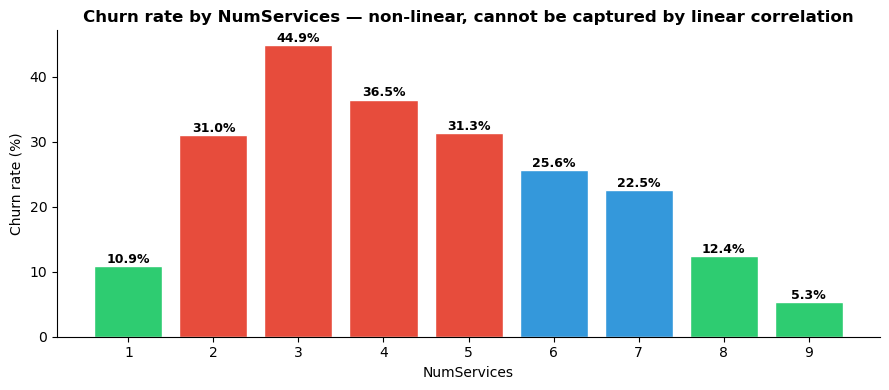

Saved: p06_numservices_churn.png


In [15]:
df['NumServices'] = (
    (df['PhoneService']    == 'Yes').astype(int) +
    (df['MultipleLines']   == 'Yes').astype(int) +
    (df['InternetService'] != 'No' ).astype(int) +
    (df['OnlineSecurity']  == 'Yes').astype(int) +
    (df['OnlineBackup']    == 'Yes').astype(int) +
    (df['DeviceProtection']== 'Yes').astype(int) +
    (df['TechSupport']     == 'Yes').astype(int) +
    (df['StreamingTV']     == 'Yes').astype(int) +
    (df['StreamingMovies'] == 'Yes').astype(int)
)

print(f'NumServices range: {df["NumServices"].min()} – {df["NumServices"].max()}')
print()

# Non-linear churn signal validation
ns_churn = df.groupby('NumServices')['Churn'].agg(['mean','count'])
ns_churn['churn_%'] = (ns_churn['mean'] * 100).round(1)
print('Churn rate by NumServices (non-linear relationship):')
display(ns_churn[['count','churn_%']])

r_linear = df['NumServices'].corr(df['Churn'])
print(f'Linear correlation with Churn: {r_linear:.4f}')
print('Near-zero linear r despite strong non-linear pattern.')
print('Peak churn at NS=3 (44.9%) — partially embedded, low switching cost.')
print('Min churn at NS=9 (5.3%)  — deeply embedded, high switching cost.')
print()

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
colors = [C_CHURN if v > 30 else C_BLUE if v > 15 else C_STAY
          for v in ns_churn['churn_%']]
bars = ax.bar(ns_churn.index, ns_churn['churn_%'],
              color=colors, edgecolor='white')
for bar, val in zip(bars, ns_churn['churn_%']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('NumServices')
ax.set_ylabel('Churn rate (%)')
ax.set_title('Churn rate by NumServices — non-linear, cannot be captured by linear correlation')
ax.set_xticks(range(1, 10))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p06_numservices_churn.png', dpi=150)
plt.show()
print('Saved: p06_numservices_churn.png')

---
## 7 · Save: telco_clean.csv

This file serves **SQL queries (Notebook 03) and Power BI dashboards**.
It contains human-readable strings and two additional business features
(`TenureGroup`, `IsAutoPayment`) that are useful for reporting
but excluded from ML training due to multicollinearity.

**Important:** `TenureGroup` and `IsAutoPayment` are created **here only** —
they do NOT appear in `telco_model_ready.csv`.

In [17]:
df_clean = df.copy()

# ── Business features for reporting ONLY (not for ML) ────────

# TenureGroup: lifecycle segments — readable for SQL and dashboards
# Rejected from ML: r=0.961 with tenure, discretisation loses info inside bins
df_clean['TenureGroup'] = pd.cut(
    df_clean['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['New', 'Junior', 'Mid', 'Loyal'],
    include_lowest=True
).astype(str)

# IsAutoPayment: payment type flag — useful KPI for dashboards
# Rejected from ML: IsAutoPayment = 1 - PM_Electronic - PM_Mailed (r=1.000)
auto_methods = ['Bank transfer (automatic)', 'Credit card (automatic)']
df_clean['IsAutoPayment'] = df_clean['PaymentMethod'].isin(auto_methods).astype(int)

# Convert all category cols to str before saving
# CSV does not preserve dtype category — explicit conversion ensures
# readable strings in output (not category codes)
for col in df_clean.select_dtypes('category').columns:
    df_clean[col] = df_clean[col].astype(str)

clean_path = OUTPUT_DIR / 'telco_clean.csv'
df_clean.to_csv(clean_path, index=False)

print(f'telco_clean.csv saved → {clean_path}')
print(f'Shape  : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
print()
print('Columns:')
for col in df_clean.columns:
    dtype  = str(df_clean[col].dtype)
    sample = str(df_clean[col].iloc[0])
    tag = '  ← business reporting only' if col in ['TenureGroup','IsAutoPayment'] else ''
    print(f'  {col:30s} {dtype:10s} sample={sample}{tag}')
print()
print('Used for: Notebook 03 (SQLite), Power BI dashboards')
print('Contains: human-readable strings + TenureGroup + IsAutoPayment')

telco_clean.csv saved → C:\Users\natal\Documents\churn_project\outputs\telco_clean.csv
Shape  : 7,043 rows × 24 columns

Columns:
  customerID                     object     sample=7590-VHVEG
  gender                         object     sample=Female
  SeniorCitizen                  object     sample=No
  Partner                        object     sample=Yes
  Dependents                     object     sample=No
  tenure                         int64      sample=1
  PhoneService                   object     sample=No
  MultipleLines                  object     sample=No
  InternetService                object     sample=DSL
  OnlineSecurity                 object     sample=No
  OnlineBackup                   object     sample=Yes
  DeviceProtection               object     sample=No
  TechSupport                    object     sample=No
  StreamingTV                    object     sample=No
  StreamingMovies                object     sample=No
  Contract                       object     sa

---
## 8 · Correlation analysis

Before ML encoding, we run a correlation check to validate
that the remaining features carry real signal.

Feature correlations with Churn:


,correlation,abs_correlation,direction,strength
Contract_num,-0.3967,0.3967,higher → LESS churn,STRONG
tenure,-0.3522,0.3522,higher → LESS churn,STRONG
IS_Fiber,0.3080,0.3080,higher → MORE churn,STRONG
PM_Elec,0.3019,0.3019,higher → MORE churn,STRONG
TotalCharges,-0.1983,0.1983,higher → LESS churn,MODERATE
MonthlyCharges,0.1934,0.1934,higher → MORE churn,MODERATE
PaperlessBilling,0.1918,0.1918,higher → MORE churn,MODERATE
OnlineSecurity,-0.1712,0.1712,higher → LESS churn,MODERATE
Dependents,-0.1642,0.1642,higher → LESS churn,MODERATE
SeniorCitizen,0.1509,0.1509,higher → MORE churn,MODERATE



Note: NumServices shows near-zero LINEAR correlation (-0.019)
but has strong NON-LINEAR signal (peak churn at NS=3: 44.9%).
Pearson r only captures linear relationships — tree models will find it.


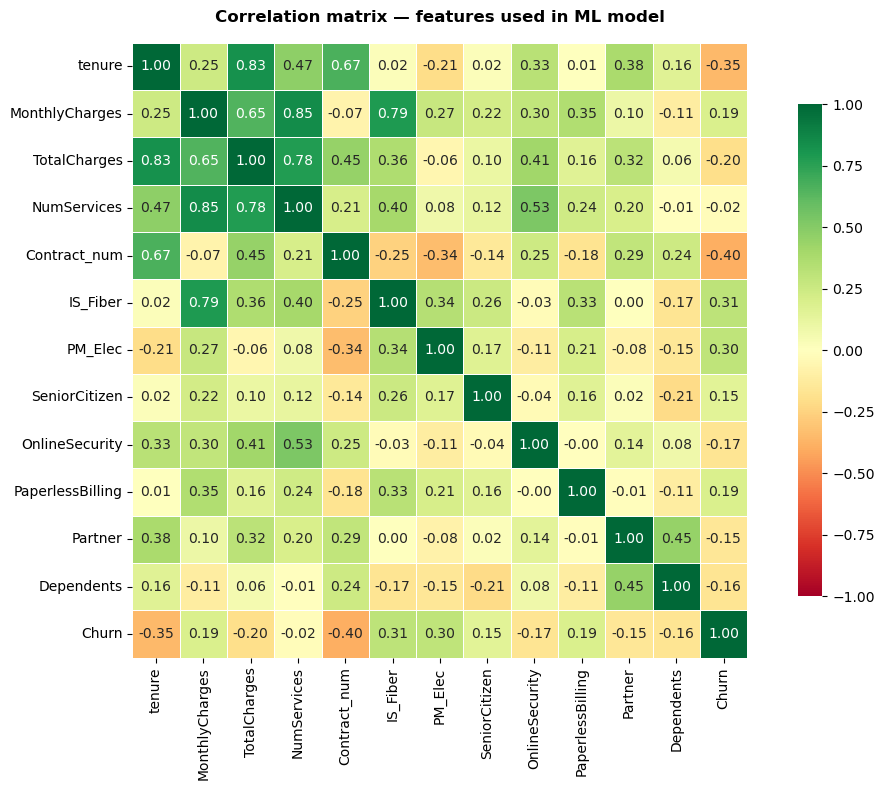

Saved: p07_correlation_matrix.png


In [19]:
# Temporary numeric encoding for correlation only
df_corr = df.copy()
binary_tmp = ['gender','SeniorCitizen','Partner','Dependents','PhoneService',
              'MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection',
              'TechSupport','StreamingTV','StreamingMovies','PaperlessBilling']
for col in binary_tmp:
    df_corr[col] = (df_corr[col] == 'Yes').astype(int)
df_corr['gender']   = (df_corr['gender'] == 'Male').astype(int)
df_corr['Contract_num'] = df_corr['Contract'].map(
    {'Month-to-month':0,'One year':1,'Two year':2})
df_corr['IS_Fiber'] = (df_corr['InternetService'] == 'Fiber optic').astype(int)
df_corr['PM_Elec']  = (df_corr['PaymentMethod'] == 'Electronic check').astype(int)

feature_cols = ['tenure','MonthlyCharges','TotalCharges','NumServices',
                'Contract_num','IS_Fiber','PM_Elec','SeniorCitizen',
                'OnlineSecurity','PaperlessBilling','Partner','Dependents']

corr = df_corr[feature_cols + ['Churn']].corr()['Churn'].drop('Churn')
corr_sorted = corr.abs().sort_values(ascending=False)

corr_df = pd.DataFrame({
    'correlation'    : corr[corr_sorted.index].round(4),
    'abs_correlation': corr_sorted.round(4),
    'direction'      : corr[corr_sorted.index].apply(
                           lambda x: 'higher → MORE churn' if x > 0
                           else 'higher → LESS churn'),
    'strength'       : corr_sorted.apply(
                           lambda x: 'STRONG'   if x > 0.3
                           else 'MODERATE' if x > 0.1
                           else 'WEAK'),
})
print('Feature correlations with Churn:')
display(corr_df)
print()
print('Note: NumServices shows near-zero LINEAR correlation (-0.019)')
print('but has strong NON-LINEAR signal (peak churn at NS=3: 44.9%).')
print('Pearson r only captures linear relationships — tree models will find it.')

# Heatmap
corr_matrix = df_corr[feature_cols + ['Churn']].corr()
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation matrix — features used in ML model', pad=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p07_correlation_matrix.png', dpi=150)
plt.show()
print('Saved: p07_correlation_matrix.png')

---
## 9 · Encode for ML: telco_model_ready.csv

sklearn requires all features to be numeric. Three encoding strategies:

| Strategy | When to use | Applied to |
|---|---|---|
| **Label (0/1)** | Binary — 2 categories only | 13 Yes/No cols + gender |
| **Ordinal (0,1,2)** | Ordered categories | Contract |
| **One-Hot** | Nominal multi-class — no order | InternetService, PaymentMethod |

### OHE baseline choices

**InternetService** — drop `'No'` explicitly (NOT alphabetical default `'DSL'`):
- `'No'` has lowest churn (7.4%) → natural reference baseline
- Both remaining coefficients show increase vs no-internet
- Eliminates perfect multicollinearity with a hypothetical HasInternet feature

**PaymentMethod** — drop `'Bank transfer (automatic)'` (alphabetically first, reasonable baseline at 16.7% churn)

In [21]:
df_model = df.copy()

# Drop identifier
df_model = df_model.drop(columns=['customerID'])

# ── Label Encoding: binary Yes/No columns ────────────────────
binary_yes_no = [
    'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaperlessBilling',
]
for col in binary_yes_no:
    df_model[col] = (df_model[col] == 'Yes').astype('int32')

# gender: Female=0, Male=1
df_model['gender'] = (df_model['gender'] == 'Male').astype('int32')

# ── Ordinal Encoding: Contract ────────────────────────────────
# .astype('int32') is CRITICAL — without it, category dtype is preserved
# even though values are now numbers, causing sklearn errors
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df_model['Contract'] = df_model['Contract'].map(contract_map).astype('int32')

# ── One-Hot Encoding: InternetService ────────────────────────
# Drop 'No' explicitly — lowest risk baseline (7.4% churn)
# NOT drop_first which would drop 'DSL' alphabetically
is_dummies = pd.get_dummies(
    df_model['InternetService'],
    prefix='InternetService',
    dtype='int32'
)
is_dummies = is_dummies.drop(columns=['InternetService_No'])
df_model = pd.concat(
    [df_model.drop(columns=['InternetService']), is_dummies], axis=1
)

# ── One-Hot Encoding: PaymentMethod ──────────────────────────
# drop_first=True removes 'Bank transfer (automatic)' — alphabetically first
# and a reasonable business baseline (16.7% churn)
pm_dummies = pd.get_dummies(
    df_model['PaymentMethod'],
    prefix='PaymentMethod',
    drop_first=True,
    dtype='int32'
)
df_model = pd.concat(
    [df_model.drop(columns=['PaymentMethod']), pm_dummies], axis=1
)

# ── Unify all integer dtypes to int32 ────────────────────────
for col in df_model.select_dtypes(['int64', 'category']).columns:
    df_model[col] = df_model[col].astype('int32')

print(f'Shape: {df_model.shape[0]:,} rows × {df_model.shape[1]} columns')
print()
print('Dtype counts:')
print(df_model.dtypes.value_counts())
print()

print('Complete column inventory:')
encoding_notes = {
    'gender'                                     : 'Label       Male=1, Female=0',
    'SeniorCitizen'                              : 'Label       Yes=1, No=0',
    'Partner'                                    : 'Label       Yes=1, No=0',
    'Dependents'                                 : 'Label       Yes=1, No=0',
    'tenure'                                     : 'Numeric     months 0–72 (unchanged)',
    'PhoneService'                               : 'Label       Yes=1, No=0',
    'MultipleLines'                              : 'Label       Yes=1, No=0',
    'OnlineSecurity'                             : 'Label       Yes=1, No=0',
    'OnlineBackup'                               : 'Label       Yes=1, No=0',
    'DeviceProtection'                           : 'Label       Yes=1, No=0',
    'TechSupport'                                : 'Label       Yes=1, No=0',
    'StreamingTV'                                : 'Label       Yes=1, No=0',
    'StreamingMovies'                            : 'Label       Yes=1, No=0',
    'Contract'                                   : 'Ordinal     Mth=0, 1yr=1, 2yr=2',
    'PaperlessBilling'                           : 'Label       Yes=1, No=0',
    'MonthlyCharges'                             : 'Numeric     monthly payment EUR (unchanged)',
    'TotalCharges'                               : 'Numeric     cumulative payment EUR (unchanged)',
    'Churn'                                      : 'TARGET      Yes=1, No=0',
    'NumServices'                                : 'Engineered  count of active services 1–9',
    'InternetService_DSL'                        : 'OHE         1 if DSL, baseline=No (7.4% churn)',
    'InternetService_Fiber optic'                : 'OHE         1 if Fiber, baseline=No',
    'PaymentMethod_Credit card (automatic)'      : 'OHE         1 if Credit card',
    'PaymentMethod_Electronic check'             : 'OHE         1 if Electronic check (45.3% churn)',
    'PaymentMethod_Mailed check'                 : 'OHE         1 if Mailed check',
}
print(f'  {"Column":45s} {"dtype":8s} {"unique":6s}  Encoding')
print('  ' + '─' * 90)
for col in df_model.columns:
    dtype  = str(df_model[col].dtype)
    unique = df_model[col].nunique()
    note   = encoding_notes.get(col, '')
    marker = '★ ' if col == 'Churn' else '  '
    print(f'{marker}{col:45s} {dtype:8s} {unique:6d}  {note}')

Shape: 7,043 rows × 24 columns

Dtype counts:
int32      22
float64     2
Name: count, dtype: int64

Complete column inventory:
  Column                                        dtype    unique  Encoding
  ──────────────────────────────────────────────────────────────────────────────────────────
  gender                                        int32         2  Label       Male=1, Female=0
  SeniorCitizen                                 int32         2  Label       Yes=1, No=0
  Partner                                       int32         2  Label       Yes=1, No=0
  Dependents                                    int32         2  Label       Yes=1, No=0
  tenure                                        int32        73  Numeric     months 0–72 (unchanged)
  PhoneService                                  int32         2  Label       Yes=1, No=0
  MultipleLines                                 int32         2  Label       Yes=1, No=0
  OnlineSecurity                                int32         2  

---
## 10 · Final validation

In [23]:
print('═' * 65)
print('FINAL VALIDATION — telco_model_ready.csv')
print('═' * 65)
print()

checks = [
    ('Rows preserved (7,043)',
     df_model.shape[0] == 7043,
     f'{df_model.shape[0]:,} rows — no rows dropped'),

    ('Columns (24)',
     df_model.shape[1] == 24,
     f'{df_model.shape[1]} columns'),

    ('No NaN values',
     df_model.isna().sum().sum() == 0,
     f'{df_model.isna().sum().sum()} NaN'),

    ('No category dtype',
     len(df_model.select_dtypes("category").columns) == 0,
     'All columns are numeric'),

    ('No object/string dtype',
     len(df_model.select_dtypes("object").columns) == 0,
     'Ready for sklearn'),

    ('Churn is 0/1',
     set(df_model['Churn'].unique()) == {0, 1},
     f'values={sorted(df_model["Churn"].unique())}'),

    ('TotalCharges no NaN',
     df_model['TotalCharges'].isna().sum() == 0,
     '0 NaN — imputation successful'),

    ('TenureGroup NOT present',
     'TenureGroup' not in df_model.columns,
     'Excluded — r=0.961 with tenure'),

    ('AvgMonthlySpend NOT present',
     'AvgMonthlySpend' not in df_model.columns,
     'Excluded — r=0.996 with MonthlyCharges'),

    ('IsAutoPayment NOT present',
     'IsAutoPayment' not in df_model.columns,
     'Excluded — 100% reconstructable from PM columns'),

    ('NumServices present',
     'NumServices' in df_model.columns,
     'Only valid engineered feature — non-linear signal'),

    ('InternetService_No NOT present',
     'InternetService_No' not in df_model.columns,
     'Dropped as OHE baseline — lowest churn 7.4%'),

    ('Bank transfer NOT present',
     'PaymentMethod_Bank transfer (automatic)' not in df_model.columns,
     'Dropped as OHE baseline — alphabetically first'),
]

all_passed = True
for check_name, passed, detail in checks:
    status = 'PASS' if passed else 'FAIL'
    if not passed:
        all_passed = False
    print(f'  [{status}] {check_name}')
    print(f'         {detail}')

print()
if all_passed:
    print('All checks PASSED.')
    print()
    # Save model-ready
    model_path = OUTPUT_DIR / 'telco_model_ready.csv'
    df_model.to_csv(model_path, index=False)
    print(f'telco_model_ready.csv saved → {model_path}')
    print(f'Shape: {df_model.shape[0]:,} rows × {df_model.shape[1]} columns')
    print()
    print('Summary:')
    print('  telco_clean.csv      → SQL, Power BI (24 cols, human-readable)')
    print('  telco_model_ready.csv → ML training  (24 cols, all numeric)')
else:
    print('Some checks FAILED — review the steps above before proceeding.')

═════════════════════════════════════════════════════════════════
FINAL VALIDATION — telco_model_ready.csv
═════════════════════════════════════════════════════════════════

  [PASS] Rows preserved (7,043)
         7,043 rows — no rows dropped
  [PASS] Columns (24)
         24 columns
  [PASS] No NaN values
         0 NaN
  [PASS] No category dtype
         All columns are numeric
  [PASS] No object/string dtype
         Ready for sklearn
  [PASS] Churn is 0/1
         values=[0, 1]
  [PASS] TotalCharges no NaN
         0 NaN — imputation successful
  [PASS] TenureGroup NOT present
         Excluded — r=0.961 with tenure
  [PASS] AvgMonthlySpend NOT present
         Excluded — r=0.996 with MonthlyCharges
  [PASS] IsAutoPayment NOT present
         Excluded — 100% reconstructable from PM columns
  [PASS] NumServices present
         Only valid engineered feature — non-linear signal
  [PASS] InternetService_No NOT present
         Dropped as OHE baseline — lowest churn 7.4%
  [PASS] Bank

---
## Summary

| Step | Action | Business rationale |
|---|---|---|
| 1 | TotalCharges → float64 + impute 11 blanks | Domain imputation: first billing cycle |
| 2 | SeniorCitizen 0/1 → Yes/No | Encoding consistency across all binary features |
| 3 | Collapse 7 redundant service labels | Remove phantom categories from ML pipeline |
| 4 | Cast 16 columns → category | 79% memory reduction |
| 5 | Churn → int64 (1/0) | Required for all sklearn estimators |
| 6 | Engineer NumServices only | Only feature with independent non-linear signal |
| 7 | Save telco_clean.csv + TenureGroup + IsAutoPayment | Business analysis, SQL, Power BI |
| 8 | Label + OHE + Ordinal encoding | Model-ready numeric matrix |
| 9 | Correlation analysis | Validate feature signal |
| 10 | 13-check validation + save model_ready | Guarantee data contract before ML |

**Rejected engineered features:**
```
AvgMonthlySpend  r=0.996 with MonthlyCharges  VIF=134  → mathematical duplicate
TenureGroup      r=0.961 with tenure                   → in clean.csv for reporting
IsAutoPayment    IsAutoPayment = 1−PM_Elec−PM_Mailed   → in clean.csv as KPI
```

**Generated outputs:**
```
outputs/
├── telco_clean.csv        
├── telco_model_ready.csv    ← ML training     (7,043 × 24 — all numeric)
├── p06_numservices_churn.png
└── p07_correlation_matrix.png
```

